# Étape 2 — Prétraitez et extrayez les features

**Projet 10** — Labellisez et appliquez des approches semi-supervisées en traitement d'images  
**Auteur :** David MEDRAGH — Mai 2026

---

## Objectif

Dans cette étape, je prépare les images (redimensionnement, normalisation) et j'utilise un modèle pré-entraîné (ResNet50) pour extraire des embeddings visuels. L'objectif est d'obtenir un vecteur de features pour chaque image, sauvegardé dans un tableau exploitable.

## Rappel de la mission

Je dispose de 1 506 IRM cérébrales : 100 labellisées (50 cancer, 50 normal) et 1 406 non étiquetées. Mon rôle est d'extraire des caractéristiques visuelles pertinentes pour alimenter les étapes de clustering (étape 3) et d'apprentissage semi-supervisé (étape 4).

## Definition of done

- [ ] Toutes les 1 506 images sont chargées avec le même pipeline, sans erreur
- [ ] Les embeddings sont extraits pour les 1 506 images via `avgpool` de ResNet50
- [ ] La dimension des features est vérifiée (1506, 2048)
- [ ] Il n'y a ni NaN ni inf
- [ ] Chaque ligne est reliée à une métadonnée claire (path, filename, dossier, label_name, label_id, is_labeled)
- [ ] Les sorties sont sauvegardées (`features.npy` + `metadata.csv`)
- [ ] Les choix techniques sont justifiés dans le notebook

## Stack technique

_Infographie à ajouter._

## Imports et versions

Je charge les bibliothèques nécessaires à cette étape :
- **torch / torchvision** : modèle pré-entraîné ResNet50, preprocessing officiel, DataLoader
- **cv2 (OpenCV)** : recommandé par l'école — utilisé ici pour charger et afficher une image en vérification
- **PIL (Pillow)** : ouverture des images pour le Dataset custom
- **numpy** : manipulation des vecteurs de features
- **pandas** : construction des métadonnées et du tableau exploitable
- **matplotlib** : visualisation

In [1]:
# Suppression des avertissements non critiques pour un affichage propre
import warnings
warnings.filterwarnings('ignore')

# --- Bibliothèques standard ---
from pathlib import Path          # Manipulation de chemins de fichiers

# --- Bibliothèques scientifiques ---
import numpy as np                # Manipulation de tableaux numériques
import pandas as pd               # DataFrames pour les métadonnées
import matplotlib.pyplot as plt   # Visualisation graphique

# --- Traitement d'images ---
from PIL import Image             # Ouverture des images pour le Dataset custom
import cv2                        # Recommandé par l'école — vérification visuelle

# --- Deep Learning / Vision ---
import torch
import torch.nn as nn
import torchvision
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader

# Affichage des versions pour traçabilité et reproductibilité
print(f"PyTorch      : {torch.__version__}")
print(f"torchvision  : {torchvision.__version__}")
print(f"OpenCV       : {cv2.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")

# Détection automatique du device (GPU si disponible, sinon CPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice       : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")

PyTorch      : 2.11.0+cu130
torchvision  : 0.26.0+cu130
OpenCV       : 4.13.0
NumPy        : 2.4.4
pandas       : 3.0.3

Device       : cpu


## Construction du dataset unifié

Je construis un DataFrame regroupant les 1 506 images du dataset avec des métadonnées complètes. Cet index unique garantit un ordre stable entre les métadonnées et les features extraites plus tard.

Colonnes :
- `path` : chemin complet de l'image
- `filename` : nom du fichier
- `dossier` : cancer / normal / sans_label
- `label_name` : "cancer" / "normal" / None
- `label_id` : 0 / 1 / `pd.NA` (nullable integer)
- `is_labeled` : True / False

In [2]:
# Racine du dataset
DATA_ROOT = Path("data/mri_dataset_brain_cancer_oc")

# Mapping des dossiers : nom → (chemin, label_name, label_id)
DOSSIERS = {
    "cancer":     (DATA_ROOT / "avec_labels" / "cancer",  "cancer",  0),
    "normal":     (DATA_ROOT / "avec_labels" / "normal",  "normal",  1),
    "sans_label": (DATA_ROOT / "sans_label",              None,      pd.NA),
}

# Construction du DataFrame unifié ligne par ligne
records = []
for dossier, (chemin, label_name, label_id) in DOSSIERS.items():
    for f in sorted(chemin.iterdir()):
        if f.is_file():
            records.append({
                "path": str(f),
                "filename": f.name,
                "dossier": dossier,
                "label_name": label_name,
                "label_id": label_id,
                "is_labeled": label_name is not None,
            })

# Créer le DataFrame et typer label_id en Int64 (nullable integer)
metadata = pd.DataFrame(records)
metadata["label_id"] = metadata["label_id"].astype("Int64")

# Résumé
print(f"Images totales  : {len(metadata)}")
print(f"Labellisées     : {metadata['is_labeled'].sum()}")
print(f"Non labellisées : {(~metadata['is_labeled']).sum()}")
print(f"\nRépartition :")
print(metadata.groupby("dossier").size())
print(f"\nAperçu :")
metadata.head()

Images totales  : 1506
Labellisées     : 100
Non labellisées : 1406

Répartition :
dossier
cancer          50
normal          50
sans_label    1406
dtype: int64

Aperçu :


,path,filename,dossier,label_name,label_id,is_labeled
0,data/mri_dataset_brain_cancer_oc/avec_labels/c...,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,cancer,cancer,0,True
1,data/mri_dataset_brain_cancer_oc/avec_labels/c...,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,cancer,cancer,0,True
2,data/mri_dataset_brain_cancer_oc/avec_labels/c...,0f718241-8f63-4b55-81ce-315324b51069.jpg,cancer,cancer,0,True
3,data/mri_dataset_brain_cancer_oc/avec_labels/c...,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,cancer,cancer,0,True
4,data/mri_dataset_brain_cancer_oc/avec_labels/c...,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,cancer,cancer,0,True


## Pipeline de preprocessing

J'utilise le preprocessing officiel fourni par `ResNet50_Weights.DEFAULT` via `weights.transforms()`. Ce pipeline inclut :
- **Resize** à 232 pixels (côté court)
- **CenterCrop** à 224×224 pixels
- **ToTensor** : conversion en tenseur [0, 1]
- **Normalize** avec les moyennes et écarts-types d'ImageNet

Ce choix garantit que les images sont prétraitées exactement comme lors de l'entraînement du modèle. Je ne définis pas de pipeline parallèle — `weights.transforms()` est la seule source de vérité.

In [3]:
# Preprocessing officiel de ResNet50 (le seul pipeline utilisé)
weights = ResNet50_Weights.DEFAULT
preprocess = weights.transforms()
print(f"Preprocessing officiel :\n{preprocess}")


# Dataset custom pour charger les IRM avec le preprocessing ResNet50
class MRIDataset(Dataset):
    """Charge chaque image depuis le DataFrame et applique le preprocessing."""

    def __init__(self, dataframe, transform):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Ouvrir l'image avec PIL et convertir en RGB (requis par ResNet50)
        img = Image.open(row["path"]).convert("RGB")
        # Appliquer le preprocessing officiel
        img_tensor = self.transform(img)
        return img_tensor, idx


# DataLoader avec shuffle=False pour conserver l'ordre stable
BATCH_SIZE = 32
dataset = MRIDataset(metadata, preprocess)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nDataset  : {len(dataset)} images")
print(f"Batches  : {len(dataloader)} (batch_size={BATCH_SIZE})")

Preprocessing officiel :
ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

Dataset  : 1506 images
Batches  : 48 (batch_size=32)


## Vérification visuelle post-preprocessing

Je vérifie visuellement que le pipeline de preprocessing fonctionne correctement. J'utilise OpenCV (`cv2`) pour charger une image brute, puis je la compare avec la version prétraitée par `weights.transforms()`. Pour afficher l'image prétraitée, je dénormalise le tenseur en inversant la normalisation ImageNet.

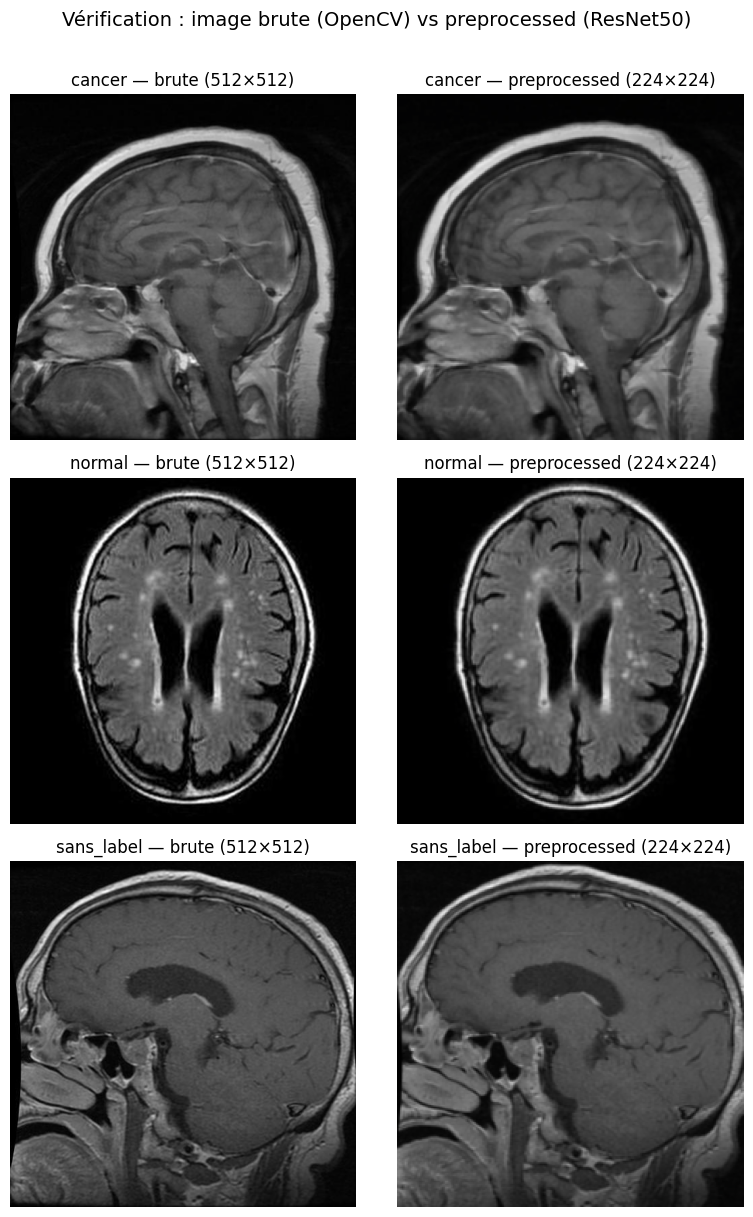

In [4]:
# Paramètres de normalisation ImageNet (utilisés par weights.transforms())
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

# Choisir une image par catégorie pour la vérification
exemples_idx = [
    metadata[metadata["dossier"] == "cancer"].index[0],
    metadata[metadata["dossier"] == "normal"].index[0],
    metadata[metadata["dossier"] == "sans_label"].index[0],
]

fig, axes = plt.subplots(3, 2, figsize=(8, 12))

for row, idx in enumerate(exemples_idx):
    img_path = metadata.loc[idx, "path"]
    dossier = metadata.loc[idx, "dossier"]

    # Colonne gauche : image brute chargée avec OpenCV (BGR → RGB)
    img_cv2 = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f"{dossier} — brute ({img_rgb.shape[1]}×{img_rgb.shape[0]})")
    axes[row, 0].axis("off")

    # Colonne droite : image après preprocessing ResNet50 (dénormalisée)
    img_tensor, _ = dataset[idx]
    img_denorm = img_tensor.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
    img_denorm = np.clip(img_denorm, 0, 1)
    axes[row, 1].imshow(img_denorm)
    axes[row, 1].set_title(f"{dossier} — preprocessed (224×224)")
    axes[row, 1].axis("off")

fig.suptitle("Vérification : image brute (OpenCV) vs preprocessed (ResNet50)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Préparation du modèle ResNet50

Je charge ResNet50 avec les poids pré-entraînés sur ImageNet et je le prépare pour l'extraction de features. Trois opérations distinctes sont nécessaires :

1. **`requires_grad = False`** sur tous les paramètres : je gèle les poids du modèle pour qu'ils ne soient pas modifiés
2. **`model.eval()`** : je passe en mode inférence (BatchNorm utilise les statistiques apprises, Dropout est désactivé)
3. **`model.fc = nn.Identity()`** : je remplace la couche de classification (1000 classes ImageNet) par une identité — la sortie du modèle devient directement le vecteur de 2 048 features issu de `avgpool`

Avec `nn.Identity()`, le forward pass produit directement un tenseur `[batch, 2048]` sans étape de flatten manuelle.

In [5]:
# Charger ResNet50 avec les poids par défaut (ImageNet)
model = resnet50(weights=weights)

# 1. Geler tous les paramètres (aucun poids ne sera modifié)
for param in model.parameters():
    param.requires_grad = False

# 2. Mode inférence (BatchNorm utilise les stats apprises, Dropout désactivé)
model.eval()

# 3. Remplacer la couche FC par Identity → sortie directe [batch, 2048]
model.fc = nn.Identity()

# Envoyer le modèle sur le device (GPU si disponible)
model = model.to(DEVICE)

# Vérification : paramètres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres totaux       : {total_params:,}")
print(f"Paramètres entraînables : {trainable_params}")
print(f"Device                  : {DEVICE}")

0.1%

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/dmedragh/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100.0%


Paramètres totaux       : 23,508,032
Paramètres entraînables : 0
Device                  : cpu


## Extraction des features

J'extrais les embeddings de toutes les 1 506 images en passant chaque batch dans le modèle ResNet50 modifié. L'extraction se fait sous `torch.no_grad()` pour éviter le calcul de gradients et économiser la mémoire.

La sortie pour chaque image est un vecteur de **2 048 features** issu de la couche `avgpool` de ResNet50.

In [6]:
# Extraction des features en batch
all_features = []

with torch.no_grad():
    for batch_idx, (images, indices) in enumerate(dataloader):
        # Envoyer les images sur le device
        images = images.to(DEVICE)

        # Forward pass → sortie [batch, 2048]
        features = model(images)

        # Stocker sur CPU en numpy
        all_features.append(features.cpu().numpy())

        # Progression toutes les 10 batches
        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(dataloader):
            print(f"  Batch {batch_idx + 1}/{len(dataloader)}")

# Concaténer tous les batches en une seule matrice
features_array = np.concatenate(all_features, axis=0)

print(f"\nShape des features : {features_array.shape}")
print(f"Attendu            : ({len(metadata)}, 2048)")
assert features_array.shape == (len(metadata), 2048), "Shape inattendue !"
print("✓ Shape correcte")

  Batch 10/48
  Batch 20/48
  Batch 30/48
  Batch 40/48
  Batch 48/48

Shape des features : (1506, 2048)
Attendu            : (1506, 2048)
✓ Shape correcte


## Sauvegarde des résultats

Je sauvegarde les features et les métadonnées dans deux fichiers séparés :
- `data/features/features.npy` : matrice numpy (1506, 2048)
- `data/features/metadata.csv` : DataFrame avec les 6 colonnes de métadonnées

Ces fichiers constituent le "tableau exploitable" demandé et seront rechargés aux étapes 3 et 4.

In [7]:
# Créer le dossier cible
FEATURES_DIR = Path("data/features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# Sauvegarder la matrice de features
np.save(FEATURES_DIR / "features.npy", features_array)
print(f"✓ Features sauvegardées : {FEATURES_DIR / 'features.npy'}")
print(f"  Shape : {features_array.shape}")

# Sauvegarder les métadonnées
metadata.to_csv(FEATURES_DIR / "metadata.csv", index=False)
print(f"✓ Métadonnées sauvegardées : {FEATURES_DIR / 'metadata.csv'}")
print(f"  Lignes : {len(metadata)}")

✓ Features sauvegardées : data/features/features.npy
  Shape : (1506, 2048)
✓ Métadonnées sauvegardées : data/features/metadata.csv
  Lignes : 1506


## Vérification de cohérence

Je recharge les fichiers sauvegardés et je vérifie :
- la correspondance entre le nombre de lignes (features vs métadonnées)
- l'absence de NaN et d'inf dans les features
- les statistiques descriptives des features

In [8]:
# Recharger depuis le disque
features_reload = np.load(FEATURES_DIR / "features.npy")
metadata_reload = pd.read_csv(FEATURES_DIR / "metadata.csv")

# Vérification de shape
print(f"Features    : {features_reload.shape}")
print(f"Métadonnées : {len(metadata_reload)} lignes")
assert features_reload.shape[0] == len(metadata_reload), "Incohérence features/métadonnées !"
print("✓ Cohérence features ↔ métadonnées")

# Vérification NaN / inf
nb_nan = np.isnan(features_reload).sum()
nb_inf = np.isinf(features_reload).sum()
print(f"\nNaN : {nb_nan}")
print(f"Inf : {nb_inf}")
assert nb_nan == 0, "Des NaN ont été détectés !"
assert nb_inf == 0, "Des Inf ont été détectés !"
print("✓ Aucun NaN ni Inf")

# Statistiques rapides sur les features
print(f"\nMin  : {features_reload.min():.4f}")
print(f"Max  : {features_reload.max():.4f}")
print(f"Mean : {features_reload.mean():.4f}")
print(f"Std  : {features_reload.std():.4f}")

Features    : (1506, 2048)
Métadonnées : 1506 lignes
✓ Cohérence features ↔ métadonnées

NaN : 0
Inf : 0
✓ Aucun NaN ni Inf

Min  : 0.0000
Max  : 8.1477
Mean : 0.1007
Std  : 0.3043


## Tableau exploitable

Je construis un DataFrame complet associant les métadonnées et les 2 048 features pour chaque image. Ce tableau est le résultat attendu de l'étape 2 : un "tableau exploitable" prêt à alimenter le clustering (étape 3) et l'apprentissage semi-supervisé (étape 4).

In [9]:
# Nommer les colonnes de features
colonnes_features = [f"feature_{i}" for i in range(features_array.shape[1])]
df_features = pd.DataFrame(features_array, columns=colonnes_features)

# Concaténer métadonnées + features
df_exploitable = pd.concat([metadata.reset_index(drop=True), df_features], axis=1)

print(f"Tableau exploitable : {df_exploitable.shape[0]} lignes × {df_exploitable.shape[1]} colonnes")
print(f"  - {len(metadata.columns)} colonnes de métadonnées : {list(metadata.columns)}")
print(f"  - {len(colonnes_features)} colonnes de features : feature_0 … feature_{features_array.shape[1]-1}")

# Aperçu des premières lignes (métadonnées + 5 premières features)
cols_apercu = list(metadata.columns) + colonnes_features[:5]
df_exploitable[cols_apercu].head(10)

Tableau exploitable : 1506 lignes × 2054 colonnes
  - 6 colonnes de métadonnées : ['path', 'filename', 'dossier', 'label_name', 'label_id', 'is_labeled']
  - 2048 colonnes de features : feature_0 … feature_2047


,path,filename,dossier,label_name,label_id,is_labeled,feature_0,feature_1,feature_2,feature_3,feature_4
0,data/mri_dataset_brain_cancer_oc/avec_labels/c...,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,cancer,cancer,0,True,0.000000,0.011748,0.274734,0.068517,0.065143
1,data/mri_dataset_brain_cancer_oc/avec_labels/c...,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,cancer,cancer,0,True,0.030363,0.016364,0.000000,0.000000,0.000000
2,data/mri_dataset_brain_cancer_oc/avec_labels/c...,0f718241-8f63-4b55-81ce-315324b51069.jpg,cancer,cancer,0,True,0.053903,0.115522,0.123226,0.000000,0.045320
3,data/mri_dataset_brain_cancer_oc/avec_labels/c...,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,cancer,cancer,0,True,0.008038,0.137191,0.020621,0.000000,0.000000
4,data/mri_dataset_brain_cancer_oc/avec_labels/c...,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,cancer,cancer,0,True,0.059723,0.043930,0.050930,0.000000,0.004721
5,data/mri_dataset_brain_cancer_oc/avec_labels/c...,27149ff6-8363-4942-a72a-eb7e38e77099.jpg,cancer,cancer,0,True,0.017768,0.000730,0.469940,0.000000,0.048756
6,data/mri_dataset_brain_cancer_oc/avec_labels/c...,2b810835-844c-49ff-b0f1-c7a71a0c696c.jpg,cancer,cancer,0,True,0.000000,0.004769,0.002156,0.000000,0.000000
7,data/mri_dataset_brain_cancer_oc/avec_labels/c...,2d662cc1-509b-4657-a208-6d181aedd5e3.jpg,cancer,cancer,0,True,0.000000,0.000000,0.000000,0.000000,0.150833
8,data/mri_dataset_brain_cancer_oc/avec_labels/c...,2fa551e9-5b85-44f6-ab71-6035b4e3f8aa.jpg,cancer,cancer,0,True,0.000000,0.007092,0.839254,0.013541,0.038490
9,data/mri_dataset_brain_cancer_oc/avec_labels/c...,3c3d07cb-ec2a-43b0-b8a3-3a51573ad930.jpg,cancer,cancer,0,True,0.190438,0.222629,0.013815,0.000000,0.005718


## Synthèse

### Choix techniques

| Choix | Justification |
|-------|---------------|
| **ResNet50** | Modèle pré-entraîné recommandé par l'école, architecture éprouvée pour l'extraction de features visuelles |
| **`ResNet50_Weights.DEFAULT`** | Poids les plus récents disponibles dans torchvision, entraînés sur ImageNet |
| **`weights.transforms()`** | Preprocessing officiel du modèle — garantit la cohérence avec les conditions d'entraînement |
| **`model.fc = nn.Identity()`** | Remplace la couche de classification par une identité → sortie directe 2048-d |
| **Couches gelées** | `requires_grad=False` : les poids ne sont pas modifiés pendant l'extraction |
| **`model.eval()`** | Mode inférence : BatchNorm et Dropout désactivés |
| **`torch.no_grad()`** | Pas de calcul de gradients → économie de mémoire |
| **OpenCV** | Recommandé par l'école — utilisé pour la vérification visuelle post-preprocessing |
| **`shuffle=False`** | Ordre stable entre métadonnées et features |

### Résultats

- **1 506 images** prétraitées et transformées en vecteurs de features
- **2 048 features** par image (sortie `avgpool` de ResNet50)
- **0 NaN, 0 Inf** — extraction propre
- **Sauvegarde** : `features.npy` (matrice) + `metadata.csv` (métadonnées à 6 colonnes)

## Definition of done — Validation

- [x] Toutes les 1 506 images sont chargées avec le même pipeline, sans erreur
- [x] Les embeddings sont extraits pour les 1 506 images via `avgpool` de ResNet50
- [x] La dimension des features est vérifiée (1506, 2048)
- [x] Il n'y a ni NaN ni inf
- [x] Chaque ligne est reliée à une métadonnée claire (path, filename, dossier, label_name, label_id, is_labeled)
- [x] Les sorties sont sauvegardées (`features.npy` + `metadata.csv`)
- [x] Les choix techniques sont justifiés dans le notebook